In [1]:
from pathlib import Path
import sys
import os

notebook_dir = Path().resolve()
project_root = notebook_dir.parent.parent
os.chdir(str(project_root))
sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pickle

sns.set_theme(style="whitegrid", context="paper", font_scale=1.75)
pd.set_option('display.float_format', '{:.3f}'.format)

# 3D Generalization: Out-Of-Distribution (OOD) Datasets

Comparing **Prompt U-Net** against **nnInteractive** on heavily OOD datasets.
Currently evaluating on the **Mouse Micro-CT and Couinaud Liver** datasets.


In [2]:
# Paths to results
results_files = {
    "Mouse": "evaluation/benchmark_nninteractive/results_mouse_p_unet_332_ssf_none_ifl_ssf_ConfidenceDrop_df0.05_20260520_112432.pkl",
    "Couinaud Liver": "evaluation/benchmark_nninteractive/results_couinaud_p_unet_332_ssf_none_ifl_ssf_ConfidenceDrop_df0.05_20260520_121702.pkl"  
}

dataframes = {}
for name, path in results_files.items():
    if path and os.path.exists(path):
        print(f"Loading {name} dataset from {path}")
        with open(path, 'rb') as f:
            records = pickle.load(f)
            
        rows = []
        for r in records:
            vol_id = r['volume_id']
            # P-UNet results
            for mode, m_res in r.get('per_mode', {}).items():
                if mode == "ssf":
                    setup = "SSF (zero interactions)"
                elif mode == "ifl_ssf":
                    setup = "SSF & IFL (matched interactions)"
                else:
                    setup = mode
                label = f"P-UNet [{mode}]"
                rows.append({
                    "dataset": name,
                    "volume_id": vol_id,
                    "model": label,
                    "vol_dice": m_res['vol_dice'],
                    "type": "Prompt U-Net",
                    "setup": setup
                })
            # nnInteractive results
            for nn_mode, nn_res in r.get('nn_results', {}).items():
                if nn_mode == "baseline":
                    setup = "SSF (zero interactions)"
                elif nn_mode == "ifl_ssf":
                    setup = "SSF & IFL (matched interactions)"
                else:
                    setup = nn_mode
                label = "nn_baseline" if nn_mode == "baseline" else f"nn+{nn_mode}"
                rows.append({
                    "dataset": name,
                    "volume_id": vol_id,
                    "model": label,
                    "vol_dice": nn_res['vol_dice'],
                    "type": "nnInteractive",
                    "setup": setup
                })
        dataframes[name] = pd.DataFrame(rows)
    else:
        print(f"Skipping {name} dataset (path not provided or file not found)")

if dataframes:
    df_long = pd.concat(dataframes.values(), ignore_index=True)
else:
    df_long = pd.DataFrame()


Loading Mouse dataset from evaluation/benchmark_nninteractive/results_mouse_p_unet_332_ssf_none_ifl_ssf_ConfidenceDrop_df0.05_20260520_112432.pkl
Loading Couinaud Liver dataset from evaluation/benchmark_nninteractive/results_couinaud_p_unet_332_ssf_none_ifl_ssf_ConfidenceDrop_df0.05_20260520_121702.pkl


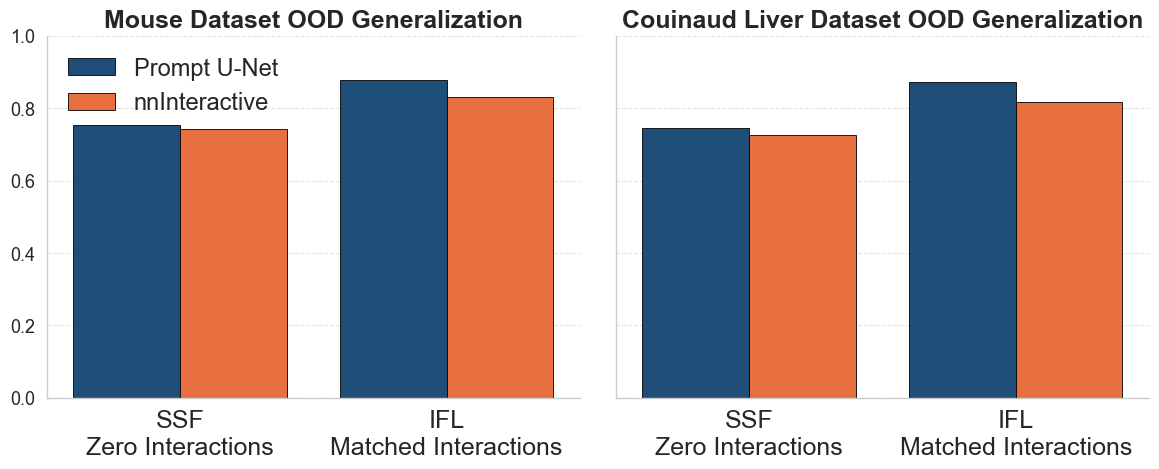

In [4]:
if not df_long.empty:
    colors = {
        "nnInteractive": "#E87040",   # orange
        "Prompt U-Net": "#1f4e79",    # deep blue
    }
    
    # We will plot the main interactive setting vs baseline
    # Filter the modes we want to display
    setups_to_plot = ["SSF (zero interactions)", "SSF & IFL (matched interactions)"]
    df_plot = df_long[df_long['setup'].isin(setups_to_plot)].copy()
    
    datasets_present = list(results_files.keys())
    
    fig, axes = plt.subplots(1, len(datasets_present), figsize=(6 * len(datasets_present), 5), squeeze=False)
    
    for i, ds_name in enumerate(datasets_present):
        ax = axes[0, i]
        df_ds = df_plot[df_plot['dataset'] == ds_name]
        
        if df_ds.empty:
            ax.set_title(f"{ds_name} (No Data)", fontsize=13, weight="bold")
            ax.axis('off')
            continue
            
        sns.barplot(
            data=df_ds, 
            x="setup", 
            y="vol_dice", 
            hue="type",
            palette=colors,
            saturation=1.0,
            edgecolor="black",
            linewidth=0.6,
            ax=ax,
            errorbar=None,
            order=setups_to_plot
        )
        
        ax.set_ylim(0, 1.0)
        ax.set_title(f"{ds_name} Dataset OOD Generalization", fontsize=18, weight="bold")
        ax.set_ylabel("")
        ax.tick_params(axis='y', labelsize=13)
            
        custom_xticks = ["SSF\nZero Interactions", "IFL\nMatched Interactions"]
        
        ax.set_xticks(range(len(custom_xticks)))
        ax.set_xticklabels(custom_xticks, fontsize=18)
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelsize=18)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="y", linestyle="--", alpha=0.5)
        
        if i == 0:
            ax.legend(title="", frameon=False, fontsize=17)
        else:
            ax.legend_.remove() if ax.get_legend() else None
            ax.tick_params(axis="y", labelleft=False)

    plt.tight_layout()
    plt.savefig("evaluation/benchmark_nninteractive/generalization_3d_ood.pdf", dpi=300, bbox_inches="tight")

In [4]:
if not df_long.empty:
    print("=== OOD Generalization Average Volumetric Dice ===\n")
    
    for ds_name in dataframes.keys():
        print(f"Dataset: {ds_name}")
        df_ds = df_long[df_long['dataset'] == ds_name]
        
        if df_ds.empty:
            print("  (No data)\n")
            continue
            
        grp = df_ds.groupby("model")["vol_dice"].agg(["mean", "std", "count"])
        
        # Display neatly
        for model in ["P-UNet [ssf]", "nn_baseline", "P-UNet [ifl_ssf]", "nn+ifl_ssf"]:
            if model in grp.index:
                mean_val = grp.loc[model, 'mean']
                std_val = grp.loc[model, 'std']
                count_val = grp.loc[model, 'count']
                print(f"  {model:16s} : {mean_val:.3f} ± {std_val:.3f}  (n={count_val})")
        print()

=== OOD Generalization Average Volumetric Dice ===

Dataset: Mouse
  P-UNet [ssf]     : 0.754 ± 0.142  (n=525)
  nn_baseline      : 0.741 ± 0.146  (n=525)
  P-UNet [ifl_ssf] : 0.877 ± 0.035  (n=525)
  nn+ifl_ssf       : 0.831 ± 0.107  (n=525)

Dataset: Couinaud Liver
  P-UNet [ssf]     : 0.746 ± 0.141  (n=600)
  nn_baseline      : 0.726 ± 0.130  (n=600)
  P-UNet [ifl_ssf] : 0.872 ± 0.039  (n=600)
  nn+ifl_ssf       : 0.818 ± 0.113  (n=600)

